# Precon Commander Deck Analysis (real per-deck decklists)

Analyzes **real, individual 100-card Commander precon decklists** pulled by
`scripts/fetch_precon_decklists.py` from Wizards of the Coast's official decklist
announcement pages (`magic.wizards.com/en/news/announcements/...-commander-decklists`),
not just the aggregate card pool for a product. Every row below is a genuine single deck
(commander(s) + 99/98 other cards = 100), matching what you'd actually open in the box.

Prices, mana values, types, rarities, color identity, and the official `game_changer`
Bracket flag come from Scryfall. **Prices are Cardmarket (EUR)**, resolved to whichever
printing of a card is currently cheapest on Cardmarket — not Scryfall's arbitrarily-chosen
"default" printing (which can even be an unreleased future reprint with no price at all).

10 of the 12 target products have published decklists (36 decks total). *Reality Fracture*
(`frc`) and *Star Trek* (`trc`) release later in 2026 and have no decklists published yet —
they're excluded here; re-run `scripts/fetch_precon_decklists.py` once WotC posts them.

## Setup

In [38]:
import json, re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 60)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = REPO_ROOT / "out" / "precon_decks"
CACHE_PATH = REPO_ROOT / "cache" / "scryfall_cache.json"

DATA_DIR, CACHE_PATH


(PosixPath('/home/apollo/Dev/deck_building_rules/out/precon_decks'),
 PosixPath('/home/apollo/Dev/deck_building_rules/cache/scryfall_cache.json'))

## Load decklists + Scryfall card data

In [39]:
cache = json.loads(CACHE_PATH.read_text())

report_files = sorted(DATA_DIR.glob("*.report.json"))
products = [json.loads(p.read_text()) for p in report_files]
products = [p for p in products if p.get("decks")]  # drop products with no published decklists yet

print(f"{len(products)} products with published decklists:\n")
for p in products:
    print(f"  {p['commander_code']:>4}  {p['commander_name']:<40} {len(p['decks'])} decks  ({p['released_at']})")

skipped = [p['commander_name'] for p in [json.loads(x.read_text()) for x in report_files] if not p.get('decks')]
if skipped:
    print(f"\nSkipped (no decklists published yet): {', '.join(skipped)}")


10 products with published decklists:

   blc  Bloomburrow Commander                    4 decks  (2024-08-02)
   drc  Aetherdrift Commander                    2 decks  (2025-02-14)
   dsc  Duskmourn: House of Horror Commander     4 decks  (2024-09-27)
   ecc  Lorwyn Eclipsed Commander                2 decks  (2026-01-23)
   eoc  Edge of Eternities Commander             2 decks  (2025-08-01)
   fic  Final Fantasy Commander                  4 decks  (2025-06-13)
   ltc  The Lord of the Rings: Tales of Middle-earth Commander 4 decks  (2023-06-23)
   msc  Marvel Super Heroes Commander            4 decks  (2026-06-26)
   soc  Secrets of Strixhaven Commander          5 decks  (2026-04-24)
   tdc  Tarkir: Dragonstorm Commander            5 decks  (2025-04-11)

Skipped (no decklists published yet): Reality Fracture Commander, Star Trek Commander


In [40]:
rows = []
deck_rows = []

for product in products:
    for deck in product["decks"]:
        deck_key = f"{product['commander_code']}::{deck['deck_title']}"
        card_counter = Counter()
        for c in deck["cards"]:
            card_counter[c["name"]] += c["quantity"]

        for name, qty in card_counter.items():
            info = cache.get(name, {})
            rows.append({
                "deck_key": deck_key,
                "product_code": product["commander_code"],
                "product_name": product["commander_name"],
                "released_at": product["released_at"],
                "deck_title": deck["deck_title"],
                "commanders": ", ".join(deck["commanders"]),
                "card_name": name,
                "quantity": qty,
                "is_commander": name in deck["commanders"],
                "price": info.get("price"),
                "cmc": info.get("cmc"),
                "type_line": info.get("type_line") or "",
                "rarity": info.get("rarity"),
                "color_identity": tuple(info.get("color_identity") or []),
                "oracle_text": info.get("oracle_text") or "",
                "game_changer": bool(info.get("game_changer")),
            })

        deck_rows.append({
            "deck_key": deck_key,
            "product_code": product["commander_code"],
            "product_name": product["commander_name"],
            "released_at": product["released_at"],
            "deck_title": deck["deck_title"],
            "commanders": ", ".join(deck["commanders"]),
            "total_cards": deck["total_cards"],
        })

cards_df = pd.DataFrame(rows)
cards_df["is_land"] = cards_df["type_line"].str.contains("Land", na=False)
cards_df["is_basic_land"] = cards_df["type_line"].str.contains("Basic Land", na=False)
cards_df["deck_label"] = cards_df["deck_title"] + "  [" + cards_df["product_code"] + "]"

decks_df = pd.DataFrame(deck_rows)
decks_df["deck_label"] = decks_df["deck_title"] + "  [" + decks_df["product_code"] + "]"

cards_expanded = cards_df.loc[cards_df.index.repeat(cards_df["quantity"])].reset_index(drop=True)

print(f"{len(decks_df)} decks, {len(cards_df)} unique (deck, card) rows, {len(cards_expanded)} total card copies")
missing_price = cards_df.loc[cards_df["price"].isna(), "card_name"].nunique()
print(f"{missing_price} unique cards still have no EUR (Cardmarket) price")
cards_df.head()


36 decks, 3144 unique (deck, card) rows, 3600 total card copies
0 unique cards still have no EUR (Cardmarket) price


,deck_key,product_code,product_name,released_at,deck_title,commanders,card_name,quantity,is_commander,price,cmc,type_line,rarity,color_identity,oracle_text,game_changer,is_land,is_basic_land,deck_label
0,blc::Animated Army,blc,Bloomburrow Commander,2024-08-02,Animated Army,"Bello, Bard of the Brambles","Bello, Bard of the Brambles",1,True,4.47,3.0,Legendary Creature — Raccoon Bard,mythic,"(G, R)","During your turn, each non-Equipment artifact and non-Au...",False,False,False,Animated Army [blc]
1,blc::Animated Army,blc,Bloomburrow Commander,2024-08-02,Animated Army,"Bello, Bard of the Brambles","Wildsear, Scouring Maw",1,False,0.64,5.0,Legendary Creature — Elemental Wolf,mythic,"(G, R)",Trample\nEnchantment spells you cast from your hand have...,False,False,False,Animated Army [blc]
2,blc::Animated Army,blc,Bloomburrow Commander,2024-08-02,Animated Army,"Bello, Bard of the Brambles","Domri, Anarch of Bolas",1,False,0.42,3.0,Legendary Planeswalker — Domri,rare,"(G, R)",Creatures you control get +1/+0.\n+1: Add {R} or {G}. Cr...,False,False,False,Animated Army [blc]
3,blc::Animated Army,blc,Bloomburrow Commander,2024-08-02,Animated Army,"Bello, Bard of the Brambles","Etali, Primal Storm",1,False,0.33,6.0,Legendary Creature — Elder Dinosaur,rare,"(R,)","Whenever Etali attacks, exile the top card of each playe...",False,False,False,Animated Army [blc]
4,blc::Animated Army,blc,Bloomburrow Commander,2024-08-02,Animated Army,"Bello, Bard of the Brambles",Prosperous Bandit,1,False,0.44,3.0,Creature — Raccoon Rogue,rare,"(R,)",Offspring {1} (You may pay an additional {1} as you cast...,False,False,False,Animated Army [blc]


## Per-deck summary

One row per real 100-card deck: price total/average, game-changer count, and land count.
This is the primary table everything else below drills into.

In [41]:
def summarize(g):
    priced = g.dropna(subset=["price"])
    priced_copies = priced["quantity"].sum()
    total_price = (priced["price"] * priced["quantity"]).sum()
    return pd.Series({
        "total_cards": g["quantity"].sum(),
        "priced_cards": priced_copies,
        "total_price_eur": round(total_price, 2),
        "avg_price_per_card": round(total_price / priced_copies, 2) if priced_copies else np.nan,
        "median_price": round(priced["price"].median(), 2) if priced_copies else np.nan,
        "game_changers": g.loc[g["game_changer"], "quantity"].sum(),
        "land_count": g.loc[g["is_land"], "quantity"].sum(),
        "basic_land_count": g.loc[g["is_basic_land"], "quantity"].sum(),
    })

deck_summary = (
    cards_df.groupby(["deck_key", "product_code", "product_name", "deck_title", "commanders", "released_at"], sort=False)
    .apply(summarize, include_groups=False)
    .reset_index()
    .sort_values("total_price_eur", ascending=False)
)
deck_summary


,deck_key,product_code,product_name,deck_title,commanders,released_at,total_cards,priced_cards,total_price_eur,avg_price_per_card,median_price,game_changers,land_count,basic_land_count
8,dsc::Endless Punishment,dsc,Duskmourn: House of Horror Commander,Endless Punishment,"Valgavoth, Harrower of Souls, The Lord of Pain",2024-09-27,100.0,100.0,124.20,1.24,0.42,0.0,38.0,16.0
25,msc::Doom Prevails,msc,Marvel Super Heroes Commander,Doom Prevails,"Doctor Doom, King of Latveria",2026-06-26,100.0,100.0,93.19,0.93,0.25,0.0,37.0,15.0
7,dsc::Miracle Worker,dsc,Duskmourn: House of Horror Commander,Miracle Worker,"Aminatou, Veil Piercer, The Master of Keys",2024-09-27,100.0,100.0,84.63,0.85,0.28,0.0,37.0,14.0
21,ltc::The Hosts of Mordor,ltc,The Lord of the Rings: Tales of Middle-earth Commander,The Hosts of Mordor,"Sauron, Lord of the Rings, Saruman, the White Hand",2023-06-23,100.0,100.0,83.00,0.83,0.26,1.0,38.0,19.0
33,tdc::Sultai Arisen,tdc,Tarkir: Dragonstorm Commander,Sultai Arisen,"Kotis, Sibsig Champion, Teval, the Balanced Scale",2025-04-11,100.0,100.0,79.62,0.80,0.25,0.0,37.0,15.0
6,dsc::Jump Scare!,dsc,Duskmourn: House of Horror Commander,Jump Scare!,"Zimone, Mystery Unraveler, Kianne, Corrupted Memory",2024-09-27,100.0,100.0,74.03,0.74,0.22,0.0,38.0,18.0
26,soc::Silverquill Influence,soc,Secrets of Strixhaven Commander,Silverquill Influence,"Killian, Decisive Mentor, Scriv, the Obligator",2026-04-24,100.0,100.0,73.42,0.73,0.37,0.0,37.0,16.0
20,ltc::Elven Council,ltc,The Lord of the Rings: Tales of Middle-earth Commander,Elven Council,"Galadriel, Elven-Queen, Gandalf, Westward Voyager",2023-06-23,100.0,100.0,70.83,0.71,0.23,0.0,38.0,26.0
24,msc::The Fantastic Four,msc,Marvel Super Heroes Commander,The Fantastic Four,"Invisible Woman, Mister Fantastic, Human Torch, The Thing",2026-06-26,100.0,100.0,70.08,0.70,0.24,0.0,37.0,17.0
3,blc::Squirreled Away,blc,Bloomburrow Commander,Squirreled Away,Hazel of the Rootbloom,2024-08-02,100.0,100.0,69.18,0.69,0.25,0.0,38.0,17.0


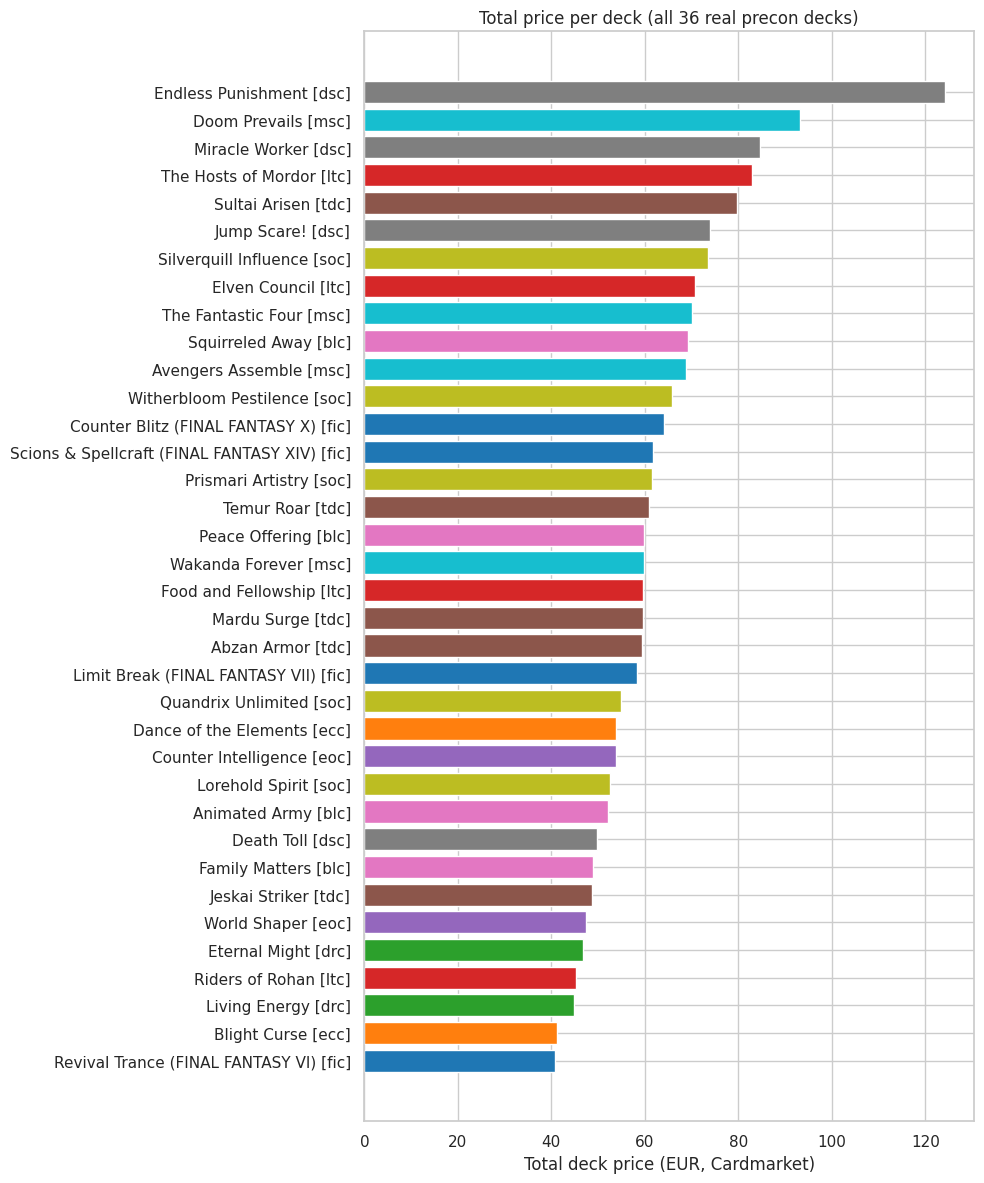

In [42]:
order = deck_summary.sort_values("total_price_eur", ascending=True)
fig, ax = plt.subplots(figsize=(10, 12))
colors = sns.color_palette("tab10", n_colors=order["product_code"].nunique())
color_map = dict(zip(order["product_code"].unique(), colors))
bar_colors = order["product_code"].map(color_map)

ax.barh(order["deck_title"] + " [" + order["product_code"] + "]", order["total_price_eur"], color=bar_colors)
ax.set_xlabel("Total deck price (EUR, Cardmarket)")
ax.set_title("Total price per deck (all 36 real precon decks)")
plt.tight_layout()
plt.show()


## Price distribution

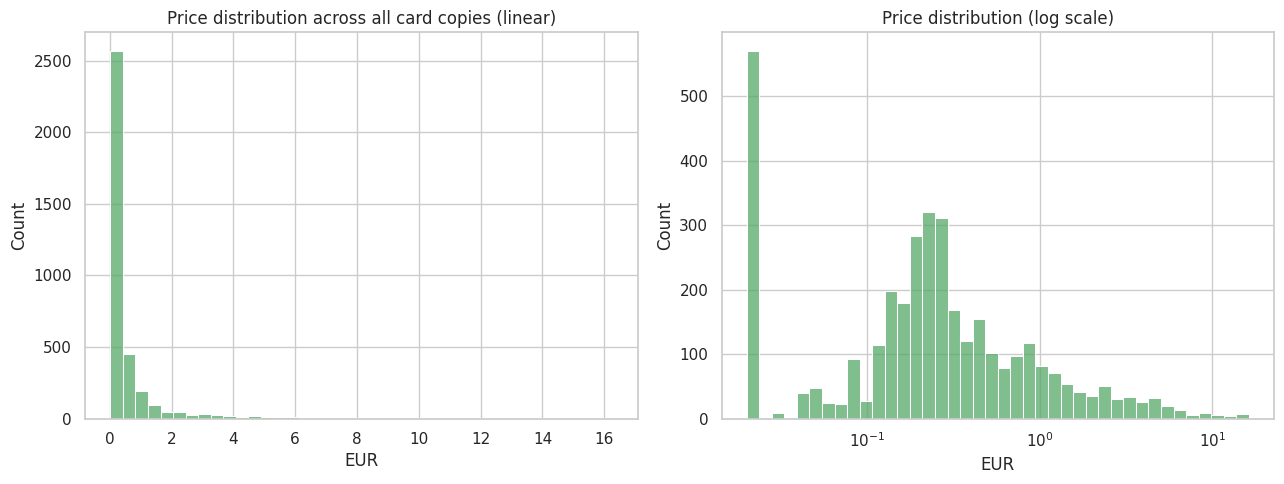

count    3600.000000
mean        0.623017
std         1.361783
min         0.020000
25%         0.120000
50%         0.230000
75%         0.500000
max        16.270000
Name: price, dtype: float64

In [43]:
priced_copies = cards_expanded.dropna(subset=["price"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(priced_copies["price"], bins=40, ax=axes[0], color="#55A868")
axes[0].set_title("Price distribution across all card copies (linear)")
axes[0].set_xlabel("EUR")

sns.histplot(priced_copies["price"], bins=40, ax=axes[1], color="#55A868", log_scale=True)
axes[1].set_title("Price distribution (log scale)")
axes[1].set_xlabel("EUR")
plt.tight_layout()
plt.show()

priced_copies["price"].describe()


### Price-range mix per deck

A heatmap reads far more clearly than 36 stacked bars once you have this many decks — each
row sums to 100% (one row per deck), color intensity shows concentration.

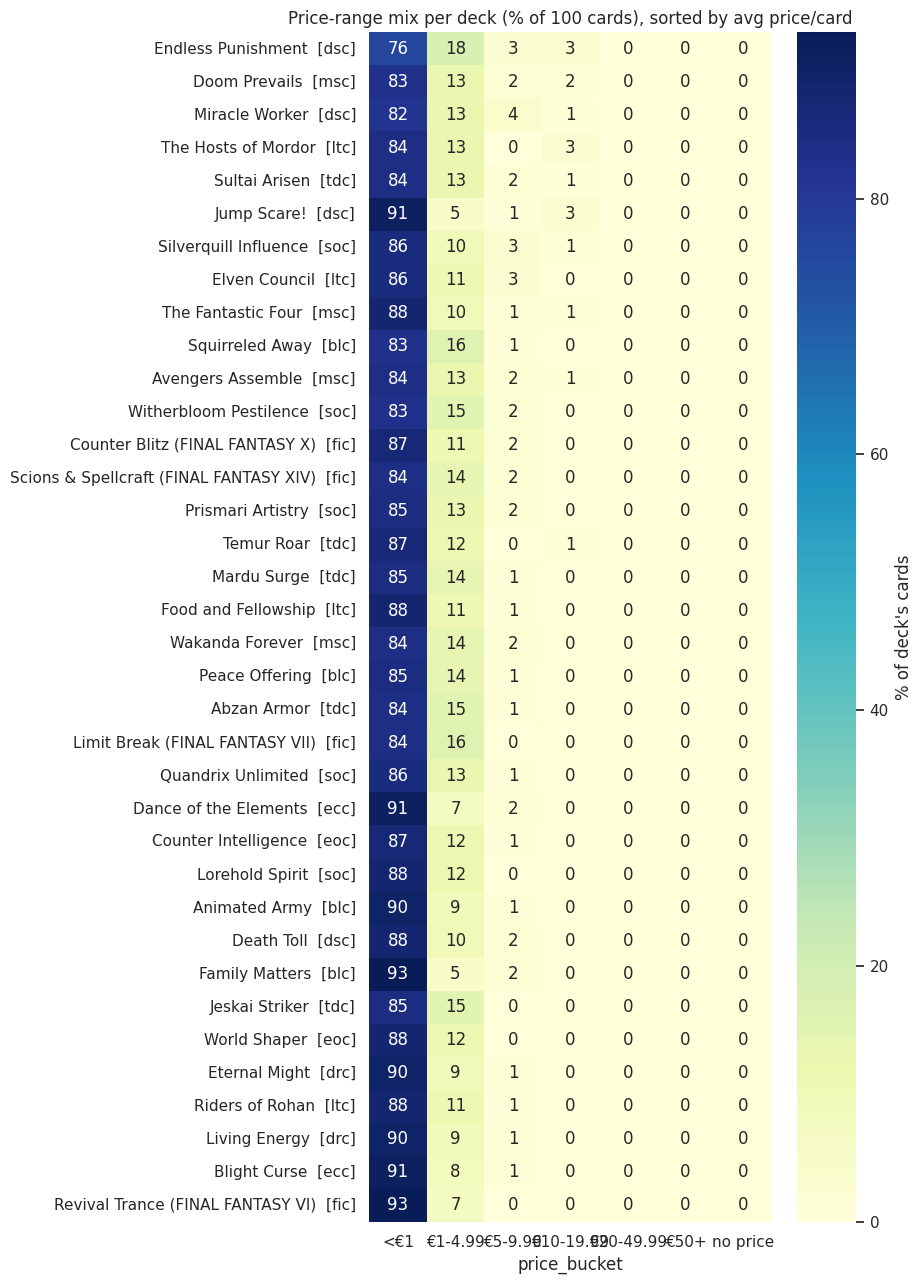

In [44]:
BUCKETS = [
    ("<€1", lambda p: p < 1),
    ("€1-4.99", lambda p: 1 <= p < 5),
    ("€5-9.99", lambda p: 5 <= p < 10),
    ("€10-19.99", lambda p: 10 <= p < 20),
    ("€20-49.99", lambda p: 20 <= p < 50),
    ("€50+", lambda p: p >= 50),
]

def bucketize(p):
    if pd.isna(p):
        return "no price"
    for label, test in BUCKETS:
        if test(p):
            return label
    return "no price"

cards_expanded["price_bucket"] = cards_expanded["price"].apply(bucketize)
bucket_order = [b[0] for b in BUCKETS] + ["no price"]

bucket_counts = (
    cards_expanded.groupby(["deck_label", "price_bucket"]).size()
    .unstack(fill_value=0)
    .reindex(columns=bucket_order, fill_value=0)
)
bucket_pct = bucket_counts.div(bucket_counts.sum(axis=1), axis=0) * 100
bucket_pct = bucket_pct.loc[deck_summary.sort_values("avg_price_per_card", ascending=False)["deck_key"].map(
    dict(zip(deck_summary["deck_key"], deck_summary["deck_title"] + "  [" + deck_summary["product_code"] + "]"))
)]

fig, ax = plt.subplots(figsize=(9, 13))
sns.heatmap(bucket_pct, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% of deck's cards"})
ax.set_title("Price-range mix per deck (% of 100 cards), sorted by avg price/card")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [45]:
top_expensive = (
    cards_df.dropna(subset=["price"])
    .sort_values("price", ascending=False)
    .drop_duplicates("card_name")
    [["card_name", "price", "deck_title", "product_name", "rarity", "game_changer", "is_commander"]]
    .head(20)
    .reset_index(drop=True)
)
top_expensive


,card_name,price,deck_title,product_name,rarity,game_changer,is_commander
0,Cavern-Hoard Dragon,16.27,The Hosts of Mordor,The Lord of the Rings: Tales of Middle-earth Commander,rare,False,False
1,"Ashaya, Soul of the Wild",16.26,Jump Scare!,Duskmourn: House of Horror Commander,mythic,False,False
2,"Valgavoth, Harrower of Souls",15.99,Endless Punishment,Duskmourn: House of Horror Commander,mythic,False,True
3,Molecule Man,15.34,Doom Prevails,Marvel Super Heroes Commander,rare,False,False
4,Persistent Constrictor,14.32,Endless Punishment,Duskmourn: House of Horror Commander,rare,False,False
5,The Fantasticar,14.26,The Fantastic Four,Marvel Super Heroes Commander,rare,False,False
6,Ondu Spiritdancer,13.85,Miracle Worker,Duskmourn: House of Horror Commander,rare,False,False
7,Giggling Skitterspike,12.86,Jump Scare!,Duskmourn: House of Horror Commander,rare,False,False
8,"Black Widow, Agile Avenger",11.87,Avengers Assemble,Marvel Super Heroes Commander,rare,False,False
9,Black Market Connections,11.85,Doom Prevails,Marvel Super Heroes Commander,rare,False,False


## Game changers

`game_changer` is Scryfall's official Commander Bracket flag for cards deemed strong enough
to single-handedly warp a game (fast mana, top-tier tutors, elite stax/combo enablers —
e.g. *Mana Vault*, *Demonic Tutor*, *Cyclonic Rift*). More game changers in a deck generally
means it plays higher on the bracket scale out of the box.

In [46]:
game_changers = (
    cards_df[cards_df["game_changer"]]
    [["card_name", "deck_title", "product_name", "price", "type_line", "is_commander"]]
    .sort_values(["product_name", "deck_title", "card_name"])
    .reset_index(drop=True)
)
print(f"{game_changers['card_name'].nunique()} unique game changer cards across {game_changers['deck_title'].nunique()} decks")
game_changers


3 unique game changer cards across 3 decks


,card_name,deck_title,product_name,price,type_line,is_commander
0,Farewell,Counter Blitz (FINAL FANTASY X),Final Fantasy Commander,3.88,Sorcery,False
1,Seedborn Muse,Abzan Armor,Tarkir: Dragonstorm Commander,6.82,Creature — Spirit,False
2,Notion Thief,The Hosts of Mordor,The Lord of the Rings: Tales of Middle-earth Commander,1.44,Creature — Human Rogue,False


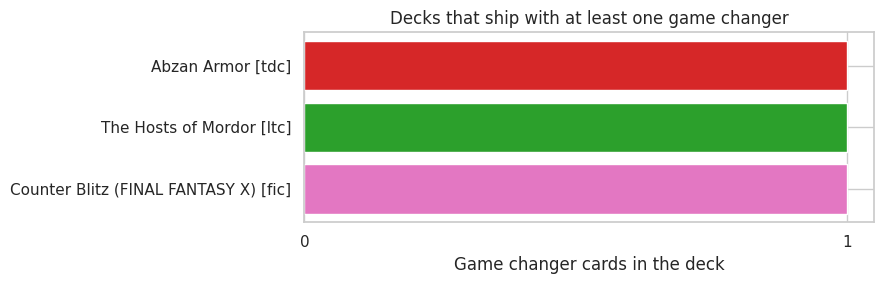

3 of 36 decks ship with 1+ game changer out of the box.


In [47]:
gc_per_deck = deck_summary.sort_values("game_changers", ascending=True)
gc_per_deck = gc_per_deck[gc_per_deck["game_changers"] > 0]

fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(gc_per_deck))))
colors = sns.color_palette("tab10", n_colors=deck_summary["product_code"].nunique())
color_map = dict(zip(deck_summary["product_code"].unique(), colors))
ax.barh(gc_per_deck["deck_title"] + " [" + gc_per_deck["product_code"] + "]", gc_per_deck["game_changers"],
        color=gc_per_deck["product_code"].map(color_map))
ax.set_xlabel("Game changer cards in the deck")
ax.set_title("Decks that ship with at least one game changer")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f"{len(gc_per_deck)} of {len(deck_summary)} decks ship with 1+ game changer out of the box.")


## Mana curve, rarity, and land base

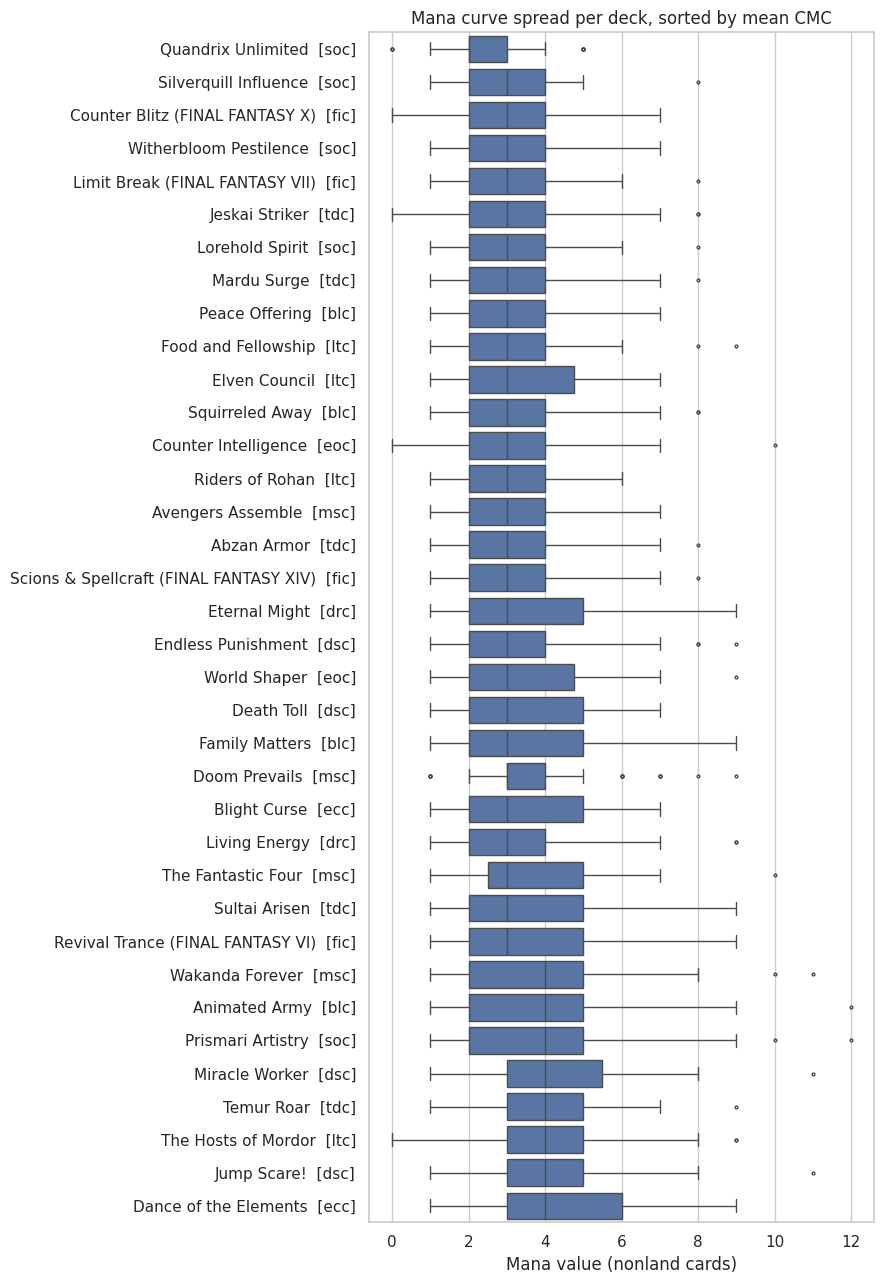

In [48]:
nonland = cards_expanded[~cards_expanded["is_land"]].dropna(subset=["cmc"])
order = nonland.groupby("deck_label")["cmc"].mean().sort_values().index

fig, ax = plt.subplots(figsize=(9, 13))
sns.boxplot(data=nonland, y="deck_label", x="cmc", order=order, ax=ax, color="#4C72B0", fliersize=2)
ax.set_xlabel("Mana value (nonland cards)")
ax.set_ylabel("")
ax.set_title("Mana curve spread per deck, sorted by mean CMC")
plt.tight_layout()
plt.show()


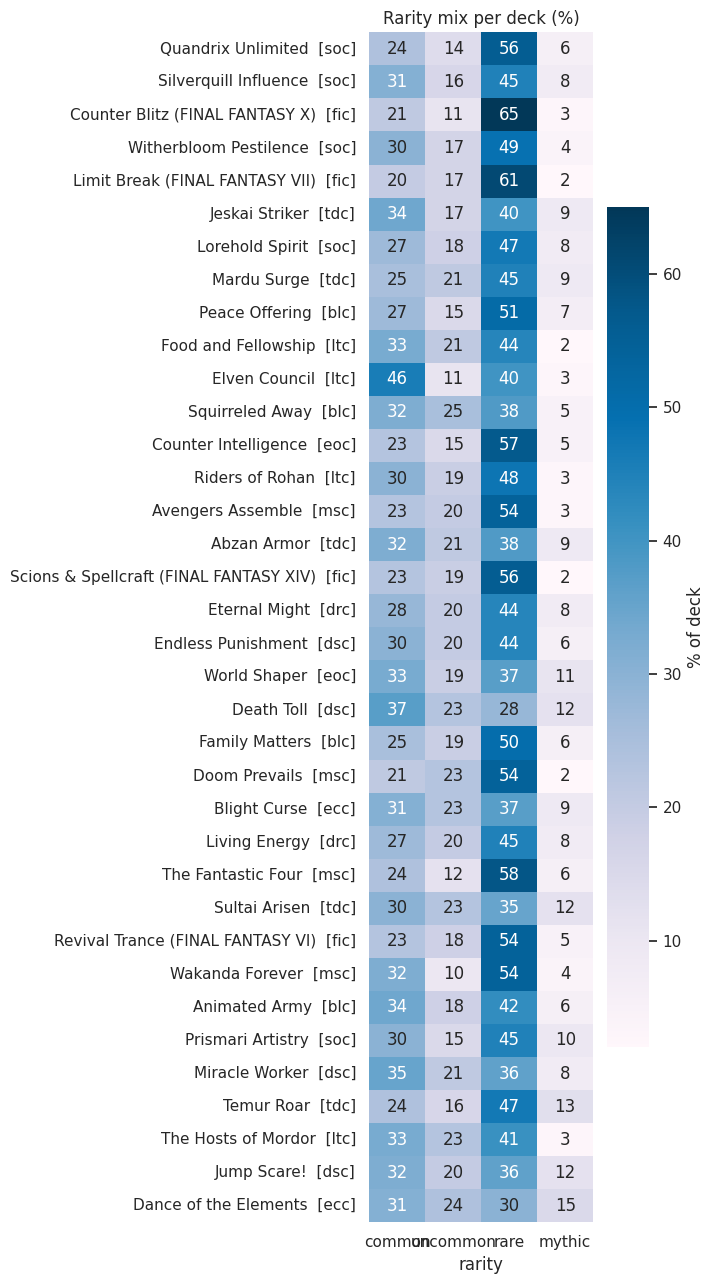

In [49]:
rarity_order = ["common", "uncommon", "rare", "mythic", "special", "bonus"]
rarity_counts = (
    cards_expanded.groupby(["deck_label", "rarity"]).size()
    .unstack(fill_value=0)
)
rarity_counts = rarity_counts[[c for c in rarity_order if c in rarity_counts.columns]]
rarity_pct = rarity_counts.div(rarity_counts.sum(axis=1), axis=0) * 100
rarity_pct = rarity_pct.reindex(order)  # same mean-CMC order as the curve chart above

fig, ax = plt.subplots(figsize=(7, 13))
sns.heatmap(rarity_pct, annot=True, fmt=".0f", cmap="PuBu", ax=ax, cbar_kws={"label": "% of deck"})
ax.set_title("Rarity mix per deck (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


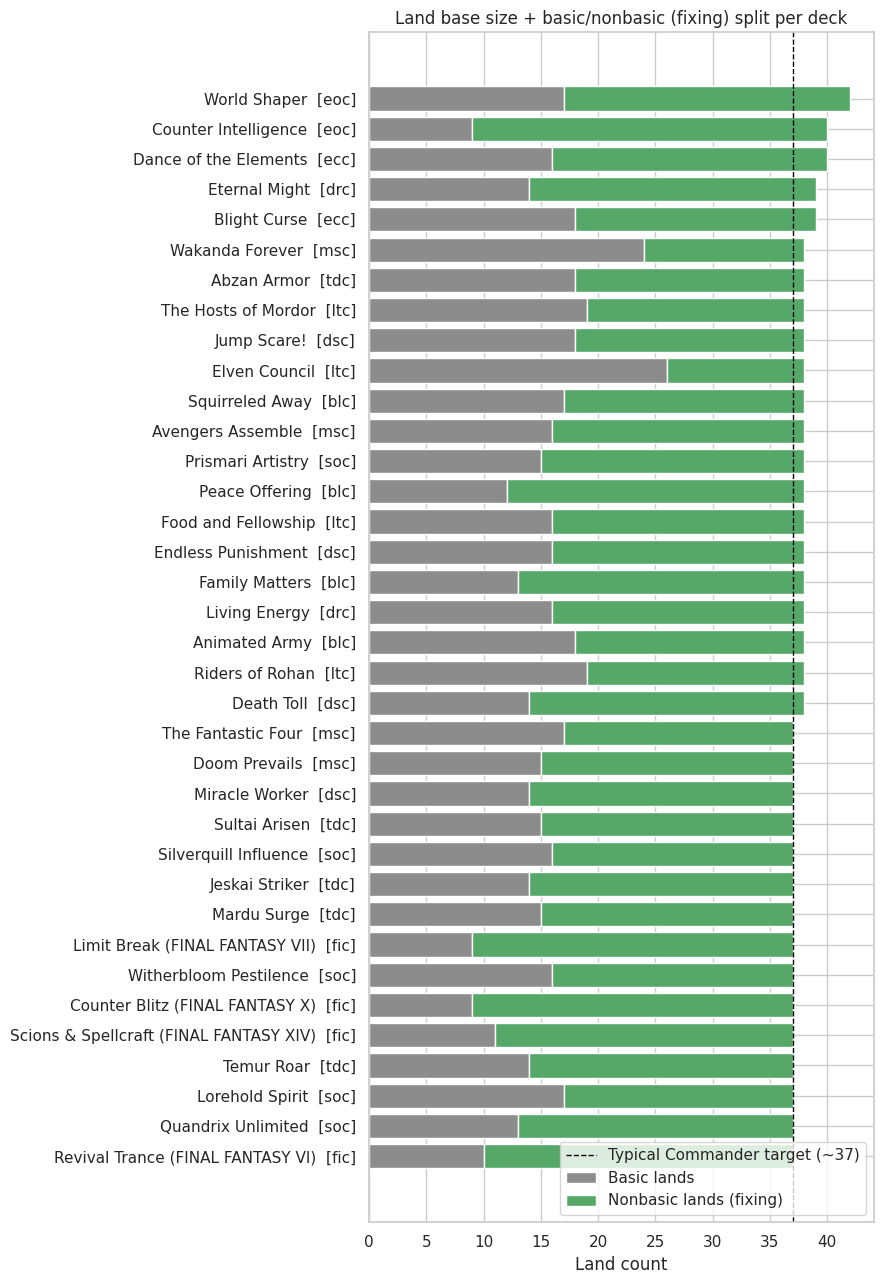

In [50]:
land_view = deck_summary.assign(
    nonbasic_lands=lambda d: d["land_count"] - d["basic_land_count"],
).sort_values("land_count")

fig, ax = plt.subplots(figsize=(9, 13))
y = np.arange(len(land_view))
ax.barh(y, land_view["basic_land_count"], color="#8C8C8C", label="Basic lands")
ax.barh(y, land_view["nonbasic_lands"], left=land_view["basic_land_count"], color="#55A868", label="Nonbasic lands (fixing)")
ax.set_yticks(y)
ax.set_yticklabels(land_view["deck_title"] + "  [" + land_view["product_code"] + "]")
ax.axvline(37, color="black", linestyle="--", linewidth=1, label="Typical Commander target (~37)")
ax.set_xlabel("Land count")
ax.set_title("Land base size + basic/nonbasic (fixing) split per deck")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Color identity balance

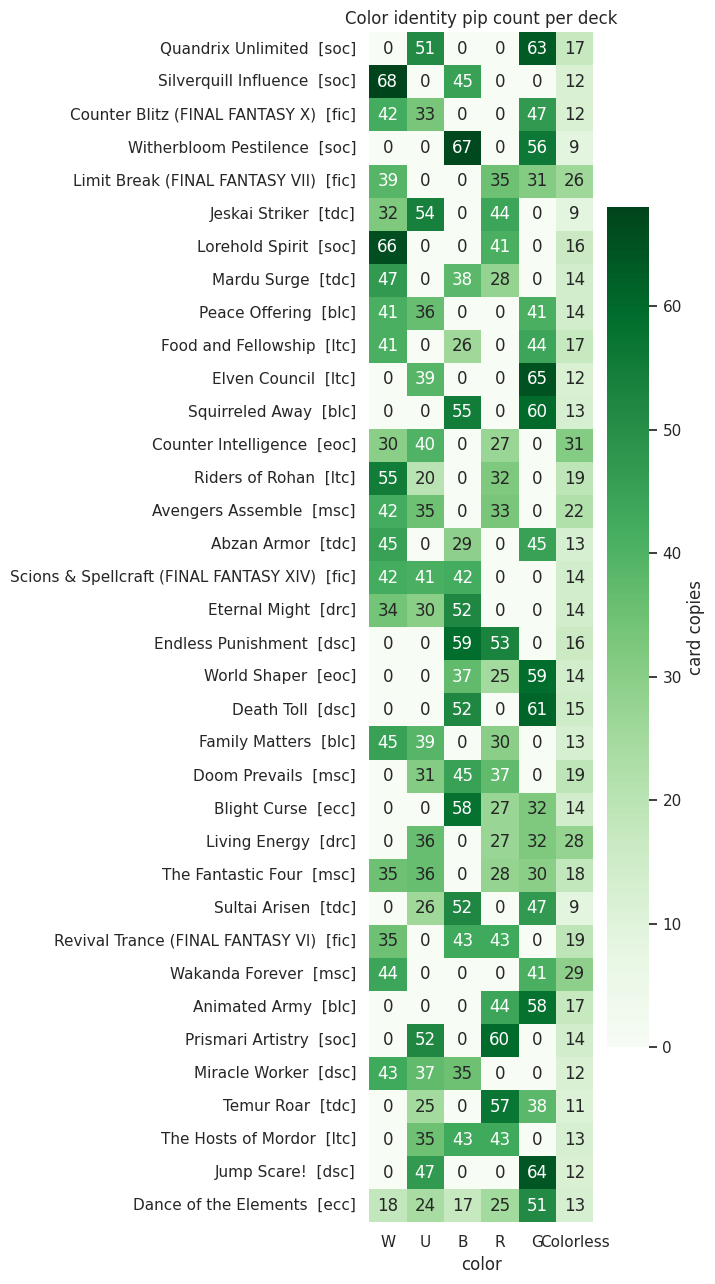

In [51]:
color_rows = []
for _, row in cards_expanded.iterrows():
    ci = row["color_identity"]
    labels = list(ci) if ci else ["Colorless"]
    for c in labels:
        color_rows.append({"deck_label": row["deck_label"], "color": c})

color_df = pd.DataFrame(color_rows)
color_order = ["W", "U", "B", "R", "G", "Colorless"]
color_pivot = (
    color_df.groupby(["deck_label", "color"]).size()
    .unstack(fill_value=0)
    .reindex(columns=color_order, fill_value=0)
    .reindex(order)
)

color_map = {"W": "#F8E7B9", "U": "#0E68AB", "B": "#4A4A4A", "R": "#D3202A", "G": "#00733E", "Colorless": "#B0B0B0"}
fig, ax = plt.subplots(figsize=(7, 13))
sns.heatmap(color_pivot, annot=True, fmt="d", cmap="Greens", ax=ax, cbar_kws={"label": "card copies"})
ax.set_title("Color identity pip count per deck")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Balance heuristics: tutors, removal, wipes, stax, fast mana, and more

Raw counts from `scripts/power_metrics.py` — the same module `scripts/generate_power_baseline.py`
uses, so these numbers match the descriptive baseline in `out/precon_decks/power_baseline.json`.
**These are informational only: no tiers, thresholds, or pass/fail rules are applied here** —
that conversation hasn't happened yet. Detection confidence varies by dial (see the module's
docstring): `game_changers` and commander keywords are exact (Scryfall-sourced); most others are
oracle-text regexes of varying precision; `card_advantage` and `protection_effects` are
deliberately broad (high recall, low precision) and should be read as a rough signal only.

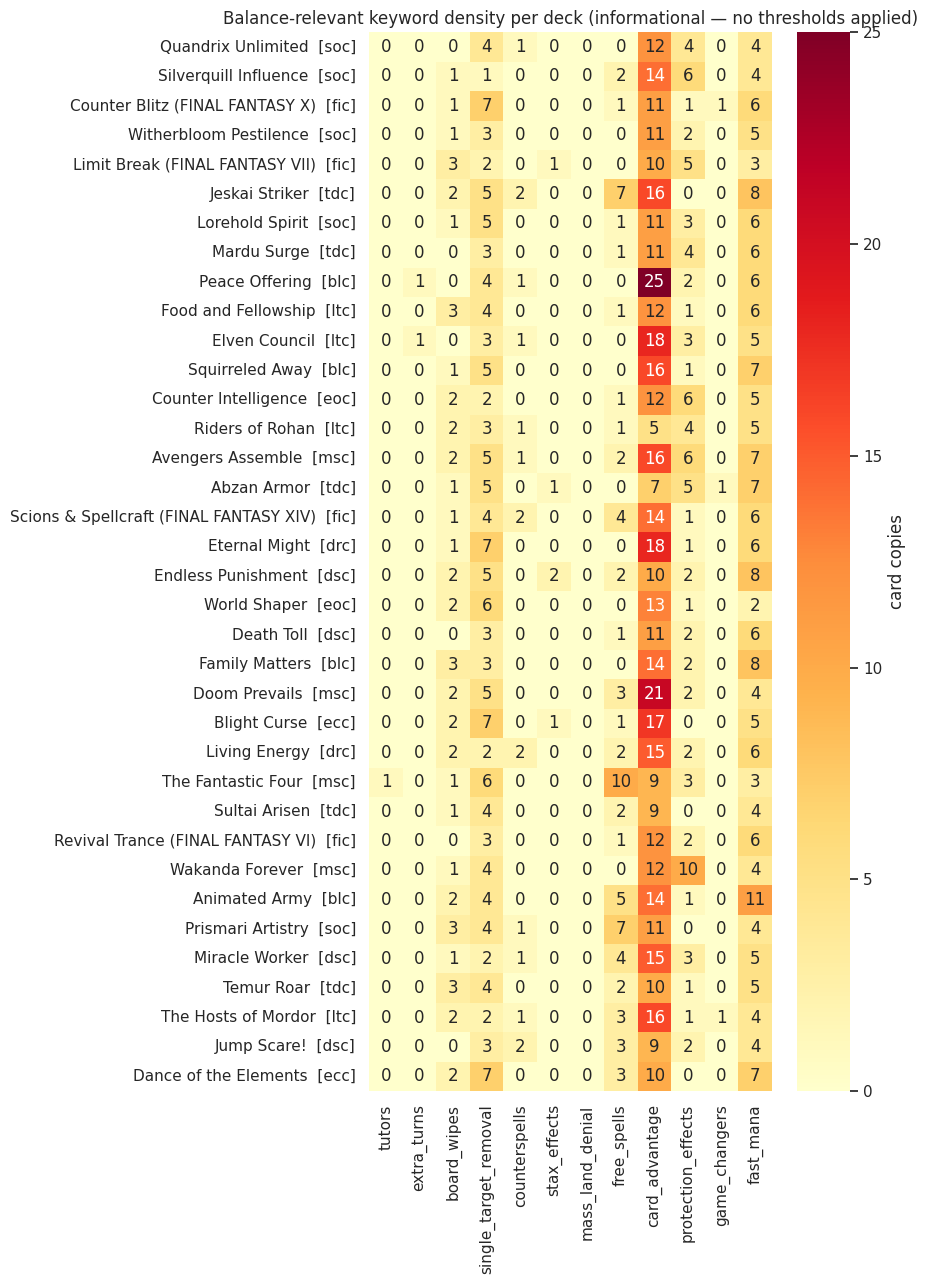

In [52]:
import sys
sys.path.insert(0, str(REPO_ROOT / "scripts"))
from power_metrics import compute_deck_stats, ALL_DIALS

deck_dial_rows = []
for product in products:
    for deck in product["decks"]:
        deck_key = f"{product['commander_code']}::{deck['deck_title']}"
        stats, _flagged = compute_deck_stats(deck["cards"], cache)
        row = {"deck_key": deck_key, "deck_label": f"{deck['deck_title']}  [{product['commander_code']}]"}
        row.update({dial: stats[dial] for dial in ALL_DIALS})
        deck_dial_rows.append(row)

dial_df = pd.DataFrame(deck_dial_rows).set_index("deck_label").reindex(order)
keyword_summary = dial_df[ALL_DIALS]

fig, ax = plt.subplots(figsize=(9, 13))
sns.heatmap(keyword_summary, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "card copies"})
ax.set_title("Balance-relevant keyword density per deck (informational — no thresholds applied)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Commander abilities: command-zone-active effects

Some commanders have abilities that matter even while sitting in the command zone
(the keyworded case is **Eminence** — read directly from Scryfall's `keywords` list, so this
is exact, not a regex guess). Freeform/unkeyworded command-zone text, if any exists among
these commanders, would NOT be caught here — informational only.

In [53]:
from power_metrics import commander_ability_flags

commander_rows = []
for product in products:
    for deck in product["decks"]:
        flags = commander_ability_flags(deck["commanders"], cache)
        for name, info in flags.items():
            commander_rows.append({
                "deck_title": deck["deck_title"],
                "product_code": product["commander_code"],
                "commander": name,
                "keywords": ", ".join(info["keywords"]) if info["keywords"] else "",
                "has_eminence": info["has_eminence"],
            })

commander_df = pd.DataFrame(commander_rows)
print(f"{commander_df['has_eminence'].sum()} of {len(commander_df)} commander slots have Eminence")
commander_df[commander_df["has_eminence"]]


0 of 67 commander slots have Eminence


,deck_title,product_code,commander,keywords,has_eminence


In [54]:
# full reference: every commander in the dataset with its raw Scryfall keywords
commander_df.sort_values(["product_code", "deck_title", "commander"]).reset_index(drop=True)


,deck_title,product_code,commander,keywords,has_eminence
0,Animated Army,blc,"Bello, Bard of the Brambles",,False
1,Family Matters,blc,"Zinnia, Valley's Voice",Flying,False
2,Peace Offering,blc,Ms. Bumbleflower,Vigilance,False
3,Squirreled Away,blc,Hazel of the Rootbloom,,False
4,Eternal Might,drc,"Hashaton, Scarab's Fist",,False
...,...,...,...,...,...
62,Mardu Surge,tdc,Zurgo Stormrender,Mobilize,False
63,Sultai Arisen,tdc,"Kotis, Sibsig Champion",,False
64,Sultai Arisen,tdc,"Teval, the Balanced Scale","Flying, Mill",False
65,Temur Roar,tdc,"Eshki, Temur's Roar",,False


## Product-level rollup

Same metrics rolled up to the 10-product level, for a quick "which precon *product* skews
pricier / higher-power" comparison (single non-stacked bars — safe at this smaller N).

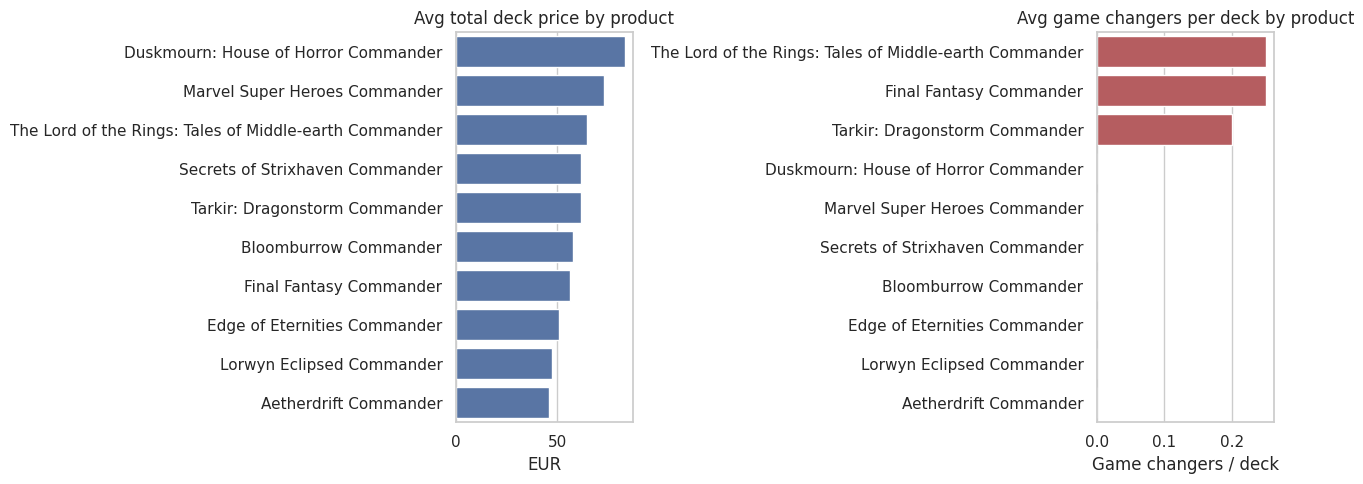

,product_code,product_name,decks,avg_deck_price,avg_price_per_card,avg_game_changers
0,dsc,Duskmourn: House of Horror Commander,4,83.1525,0.8325,0.00
1,msc,Marvel Super Heroes Commander,4,72.9700,0.7300,0.00
2,ltc,The Lord of the Rings: Tales of Middle-earth Commander,4,64.6525,0.6475,0.25
4,soc,Secrets of Strixhaven Commander,5,61.6500,0.6180,0.00
3,tdc,Tarkir: Dragonstorm Commander,5,61.6000,0.6180,0.20
5,blc,Bloomburrow Commander,4,57.5650,0.5750,0.00
6,fic,Final Fantasy Commander,4,56.2975,0.5625,0.25
8,eoc,Edge of Eternities Commander,2,50.6700,0.5050,0.00
7,ecc,Lorwyn Eclipsed Commander,2,47.5300,0.4750,0.00
9,drc,Aetherdrift Commander,2,45.8300,0.4600,0.00


In [55]:
product_summary = deck_summary.groupby(["product_code", "product_name"], sort=False).agg(
    decks=("deck_key", "nunique"),
    avg_deck_price=("total_price_eur", "mean"),
    avg_price_per_card=("avg_price_per_card", "mean"),
    avg_game_changers=("game_changers", "mean"),
).reset_index().sort_values("avg_deck_price", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=product_summary, y="product_name", x="avg_deck_price", ax=axes[0], color="#4C72B0")
axes[0].set_title("Avg total deck price by product")
axes[0].set_xlabel("EUR")
axes[0].set_ylabel("")

sns.barplot(data=product_summary.sort_values("avg_game_changers", ascending=False), y="product_name", x="avg_game_changers", ax=axes[1], color="#C44E52")
axes[1].set_title("Avg game changers per deck by product")
axes[1].set_xlabel("Game changers / deck")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

product_summary


## Suggestions / natural next steps

- **Combine `game_changer` count + tutor/extra-turn/stax density into a proxy bracket score**
  per deck, similar in spirit to the `commander-deck-evaluator` skill's 50-point scale —
  useful for sanity-checking a precon against the official Bracket system before deciding
  whether to upgrade it.
- **Nonbasic fixing ratio vs deck price**: the land-base chart above shows basic/nonbasic
  split; worth correlating against total price directly — precons often cut fixing to hit a
  price target, which matters as much as raw card price for how a deck actually plays.
- **Price-over-time**: snapshot `cache/scryfall_cache.json` periodically to track
  reprint-driven price drops for game changers/staples instead of a single point-in-time price.
- **Combo-piece detection**: the keyword heuristics above catch obvious single-card effects
  but miss two-card combos entirely — would need a curated combo database (e.g. Commander
  Spellbook's public API) to flag those.
- **Reality Fracture and Star Trek**: re-run `scripts/fetch_precon_decklists.py` after WotC
  publishes those decklists (added to `PRODUCTS` already, just waiting on a source URL) to
  bring the set to all 12 products / an estimated 44 decks.